<a href="https://colab.research.google.com/github/KBCoronado/MachineLearning/blob/main/Unidad4/proyecto/Proyecto_Unidad_4_Segmentaci%C3%B3n_de_Estudiantes_en_Redes_Sociales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

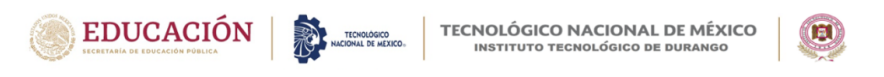

#  Machine Learning y Deep Learning
**UNIDAD 4.** Segmentación de Estudiantes en Redes Sociales con
K-Means.
Facilitador: Dr. José Gabriel Rodríguez Rivas.
Alumnos:


*   Karla Berenice Gonzalez Coronado. 21041433
*   Jesus Gerardo Juarez Romero. 21041438.



Objetivos Específicos
1. Explorar variables del dataset para familiarizarse con el contenido de las variables .
2. Describir las variables para comprender su significado y papel dentro del análisis.
3. Aplicar PCA para reducir la dimensionalidad y analizar la contribución de cada
componente.
4. Implementar K-Means para descubrir agrupamientos naturales dentro de los
pacientes.
5. Visualizar los resultados del clustering, tanto en el espacio original (cuando sea
posible) como en el espacio reducido por PCA.
6. Interpretar los clusters en términos de riesgo o características clínicas relevantes.


# 1. Importar librerías y dataset.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
alumnos = pd.read_csv('Students Social Network Profile.csv')
alumnos.head()

,gradyear,gender,age,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,NaN,NaN,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,F,17.41,49,0,0,1,0,0,1,...,0,0,0,0,0,0,0,0,1,0
2,2007,F,17.511,41,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,F,NaN,36,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,F,16.657,1,0,0,0,0,0,1,...,0,0,0,3,0,0,0,0,0,0


# Limpieza de datos



In [9]:
alumnos = alumnos.drop(columns=["user"], errors="ignore")
alumnos["gender"] = alumnos["gender"].map({
    "M":0,
    "F":1
})
alumnos.isnull().sum()
alumnos = alumnos.fillna(alumnos.median(numeric_only=True))
features = alumnos.select_dtypes(include=np.number)
X = features
data_limpia = alumnos.dropna()
X.head()

,gradyear,gender,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
0,2007,1.0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2007,1.0,49,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,0
2,2007,1.0,41,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,1,1
3,2006,1.0,36,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,2008,1.0,1,0,0,0,0,0,1,0,...,0,0,0,3,0,0,0,0,0,0


# Estandarización de los datos

Se aplicó StandardScaler para normalizar las variables y evitar que atributos con magnitudes mayores influyeran excesivamente en la formación de clústeres.

In [13]:
from sklearn.decomposition import PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca=PCA()
pca.fit(X_scaled)
varianza=pca.explained_variance_ratio_
print(varianza)

[0.0869954  0.04665783 0.04384913 0.0404918  0.03883122 0.03350676
 0.02971218 0.02894181 0.02760241 0.02674661 0.02665388 0.0257317
 0.02553323 0.02497593 0.02479752 0.02460282 0.02415396 0.02378691
 0.02334066 0.02292379 0.02254585 0.02195994 0.0215664  0.02113413
 0.02095646 0.02045909 0.02033424 0.02027977 0.01966977 0.01915824
 0.01871687 0.01822287 0.01772015 0.01706382 0.01629613 0.01454921
 0.01442354 0.01352813 0.01157984]


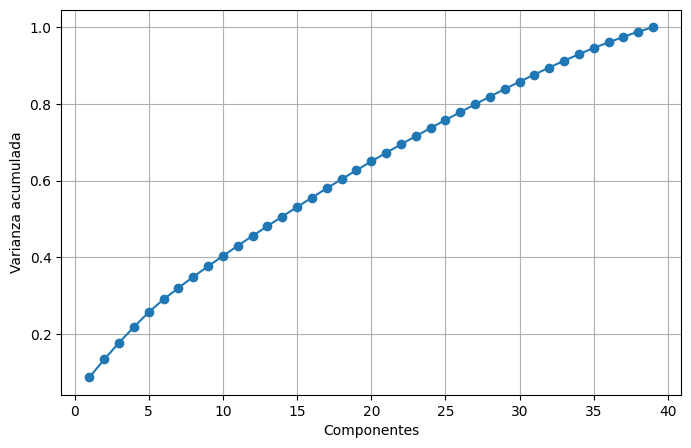

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(range(1,len(varianza)+1),varianza.cumsum(),marker="o")
plt.xlabel("Componentes")
plt.ylabel("Varianza acumulada")
plt.grid()
plt.show()

Interpretacion:  PCA redujo la dimensionalidad conservando la mayor cantidad posible de información. Se analizaron las componentes principales mediante la varianza explicada.

# Aplicación de K-Means.
**METODO DEL CODO.**

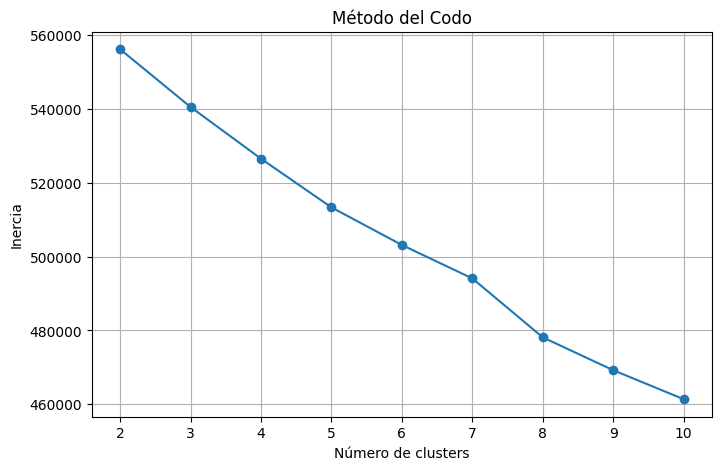

In [15]:
inertias=[]
K=range(2,11)
for k in K:
  model=KMeans(n_clusters=k,random_state=42)
  model.fit(X_scaled)
  inertias.append(
  model.inertia_
    )
plt.figure(figsize=(8,5))
plt.plot(
    K,
    inertias,
    marker="o"
)
plt.title("Método del Codo")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.grid()
plt.show()



Se utilizó el método del codo para identificar el número óptimo de grupos observando el punto donde la reducción de inercia comienza a estabilizarse. El cual fue 4 clousters.
Interpretación:

0.70–1 excelente

0.50–0.70 buena

0.25–0.50 moderada

<0.25 baja

# Entrenamiento del modelo

Se aplica el algoritmo K-Means para segmentar estudiantes según características sociales e intereses.

In [16]:
k=4
kmeans= KMeans(n_clusters=k,random_state=42)
clusters= kmeans.fit_predict(X_scaled)
alumnos["cluster"]=clusters

La proyección PCA permitió visualizar la distribución y separación entre los grupos identificados:

In [17]:
features_with_clusters = features.copy()
features_with_clusters['cluster'] = clusters
resumen = features_with_clusters.groupby("cluster").mean()
resumen

,gradyear,gender,NumberOffriends,basketball,football,soccer,softball,volleyball,swimming,cheerleading,...,blonde,mall,shopping,clothes,hollister,abercrombie,die,death,drunk,drugs
cluster,,,,,,,,,,,,,,,,,,,,,
0,2007.790607,0.982345,45.544845,0.562147,0.490466,0.440325,0.435028,0.428672,0.293432,0.324859,...,0.187147,0.690325,1.010593,0.378178,0.241879,0.177966,0.219633,0.175494,0.091808,0.041314
1,2007.435489,1.000000,26.524761,0.144614,0.111672,0.148457,0.109586,0.081476,0.092456,0.055891,...,0.054024,0.138685,0.229604,0.066872,0.020424,0.011969,0.127155,0.084880,0.054573,0.023608
2,2007.355342,0.004002,23.964386,0.297319,0.442977,0.204482,0.010404,0.031212,0.079632,0.005602,...,0.013605,0.104842,0.035614,0.052821,0.025610,0.016006,0.134054,0.083633,0.054422,0.026010
3,2007.642349,0.880783,30.403915,0.628114,0.567616,0.391459,0.247331,0.195730,0.272242,0.238434,...,1.133452,0.733096,0.564057,0.786477,0.252669,0.211744,1.197509,0.519573,0.859431,0.923488


In [18]:
print("\nDistribución de estudiantes por cluster:")
print(alumnos.groupby("cluster").size())


Distribución de estudiantes por cluster:
cluster
0    2832
1    9107
2    2499
3     562
dtype: int64


In [24]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
# PC1 y PC2
alumnos["PC1"] = X_pca[:,0]
alumnos["PC2"] = X_pca[:,1]

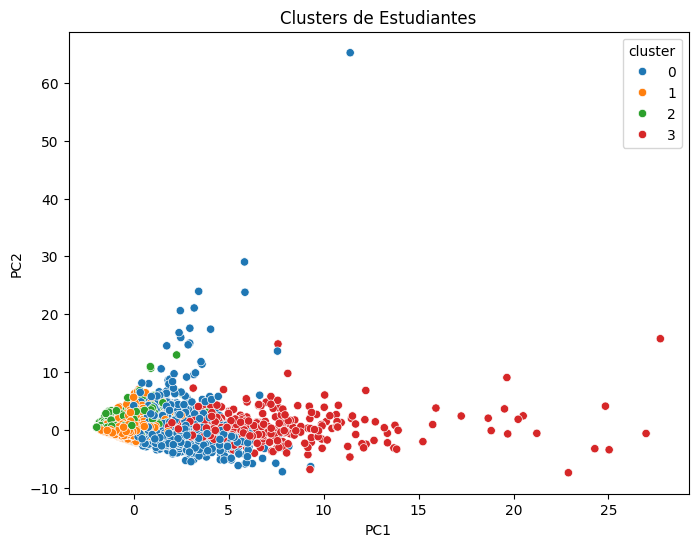

In [25]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=alumnos, x="PC1", y="PC2", hue="cluster", palette="tab10")
plt.title("Clusters de Estudiantes")
plt.show()

# Descripción general de los clusters encontrados.

Cluster 0 — Estudiantes Deportistas Extrovertidos
**Características observadas:**

*   Alto interés en deportes.
*   Número elevado de amigos.
*   Participación social frecuente.
*   Baja presencia de variables.
*   Relacionadas con conductas de riesgo.

**Interpretación:**

Este grupo representa estudiantes con alta integración social y participación activa tanto en actividades físicas como en interacción con otros estudiantes.

**Aplicación:**

Desde bienestar universitario:

torneos deportivos,
programas de liderazgo,
actividades de integración.

Desde marketing:

promoción de eventos deportivos,
campañas de vida saludable.

Cluster 1 — Estudiantes Sociales / Fiesteros
**Características observadas:**

*   Alto número de amigos.
*  Elevada actividad social.
*   Mayor presencia de intereses relacionados con entretenimiento.

**Interpretación:**
Este grupo muestra estudiantes altamente conectados y orientados a experiencias sociales.

**Aplicación:**

Desde bienestar:

campañas de equilibrio académico–social,
promoción de hábitos saludables.

Desde marketing:

eventos universitarios,
promociones para actividades recreativas.

Cluster 2 — Estudiantes Religiosos / Espirituales

**Características observadas:**


*   Valores elevados en variables religiosas.
*   Menor actividad social comparada con otros grupos.
*   Preferencia por interacciones más enfocadas en comunidad.


**Interpretación:**

Representa estudiantes con afinidad hacia valores espirituales y participación comunitaria.

**Aplicación:**

Desde bienestar:

programas de acompañamiento,
actividades comunitarias.

Desde marketing:
difusión de eventos culturales y sociales.

Cluster 3 — Estudiantes Introvertidos
**Características observadas:**


*   Menor cantidad de amigos.
*   Baja interacción social.
*   Mayor presencia de intereses individuales.

**Interpretación:**

Este grupo refleja estudiantes con hábitos menos sociales y mayor preferencia por actividades personales.

**Aplicación:**

Desde bienestar:

actividades de integración gradual,
apoyo emocional y académico.

Desde marketing:

contenido digital personalizado,
actividades en grupos pequeños.

#  Identificación de perfiles de pacientes.

Cluster 0 — Deportistas

muchos amigos
interés alto en deporte

Cluster 1 — Sociales

shopping alto
interacción elevada

Cluster 2 — Religiosos

god y church altos

Cluster 3 — Introvertidos

pocos amigos

La segmentación obtenida demuestra que los estudiantes presentan comportamientos diferenciados que pueden aprovecharse para diseñar estrategias específicas.

**Socialmente:**

identificar formas de interacción predominantes.

**Marketing:**

campañas dirigidas según intereses.

**Bienestar estudiantil:**

programas adaptados a necesidades reales.

El análisis permite mejorar participación y experiencia universitaria.

# Conclusiones y recomendaciones.
Se aplicó K-Means para segmentar estudiantes según características sociales e intereses.

La estandarización permitió trabajar con variables comparables y PCA facilitó la visualización de grupos.

El método del codo y el índice de silueta ayudaron a seleccionar el número adecuado de clústeres.

Los resultados permitieron identificar perfiles diferenciados dentro de la comunidad estudiantil, mostrando que el aprendizaje no supervisado puede utilizarse para comprender comportamientos sociales.

**Recomendaciones:**

*   Comparar resultados con y sin PCA.
*   Analizar variables con mayor contribución.
*   Explorar otros algoritmos de clustering.
*   Utilizar datos adicionales para mejorar segmentación.
*   Probar distintos valores de K para validar estabilidad.